# Level 3 - Task 2: Votes Analysis

## Objective

The objective of this task is to analyze customer voting patterns and understand how votes relate to restaurant ratings.

### This task includes:

- Analyze the distribution of customer votes.
- Identify the restaurants with the highest number of votes.
- Examine the relationship between votes and ratings.
- Visualize the findings.

### Libraries Used

- Pandas
- Matplotlib
- Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Dataset
df = pd.read_csv("../Dataset.csv")

## Step 1: Explore Votes

Display statistical information about the Votes column.

In [5]:
df["Votes"].describe()

count     9551.000000
mean       156.909748
std        430.169145
min          0.000000
25%          5.000000
50%         31.000000
75%        131.000000
max      10934.000000
Name: Votes, dtype: float64

## Step 2: Top Restaurants by Votes

Identify the restaurants that received the highest number of customer votes.

In [8]:
top_votes = df.nlargest(10, "Votes")[
    ["Restaurant Name", "City", "Votes", "Aggregate rating"]
]

top_votes

,Restaurant Name,City,Votes,Aggregate rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


## Step 3: Visualize Top Restaurants by Votes

The following chart displays the top 10 restaurants based on customer votes.

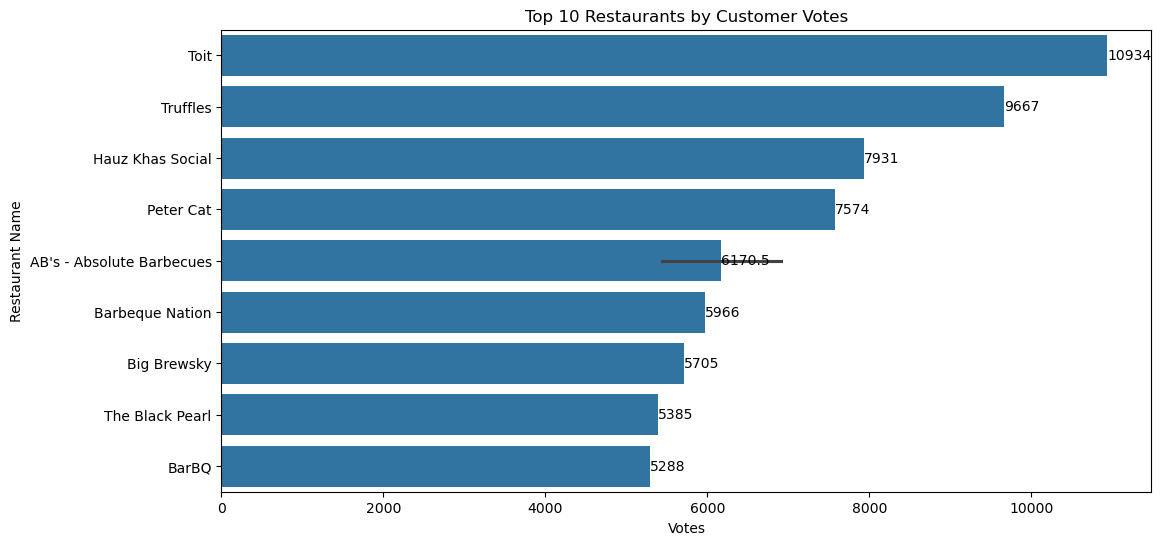

In [11]:
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_votes,
    x="Votes",
    y="Restaurant Name"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Restaurants by Customer Votes")
plt.xlabel("Votes")
plt.ylabel("Restaurant Name")

plt.savefig(
    "../images/top_restaurants_votes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 4: Relationship Between Votes and Ratings

Analyze whether restaurants with higher ratings receive more customer votes.

In [14]:
correlation = df["Votes"].corr(df["Aggregate rating"])

print("Correlation between Votes and Ratings:", round(correlation,2))

Correlation between Votes and Ratings: 0.31


## Step 5: Scatter Plot

A scatter plot is created to visualize the relationship between customer votes and aggregate ratings.

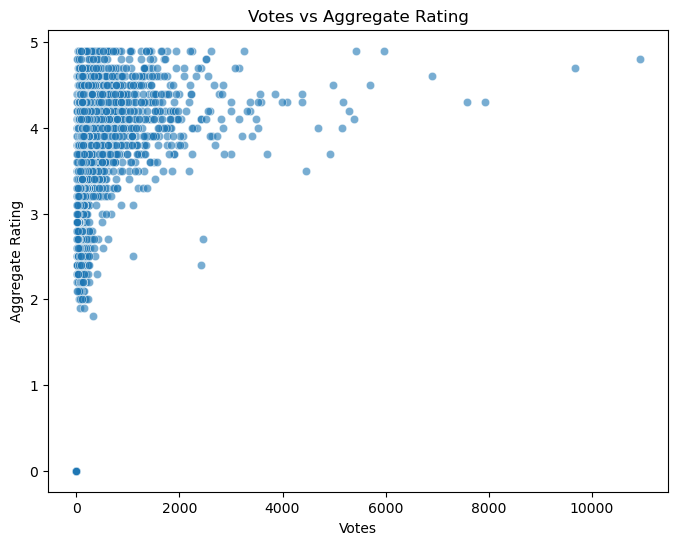

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.6
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.savefig(
    "../images/votes_vs_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 6: Average Votes by Rating Category

Calculate the average number of votes for each rating category.

In [20]:
votes_rating = (
    df.groupby("Rating text")["Votes"]
    .mean()
    .sort_values(ascending=False)
)

votes_rating

Rating text
Excellent    851.770764
Very Good    520.458758
Good         229.351429
Poor          90.715054
Average       48.249130
Not rated      0.870112
Name: Votes, dtype: float64

## Step 7: Visualize Average Votes by Rating Category

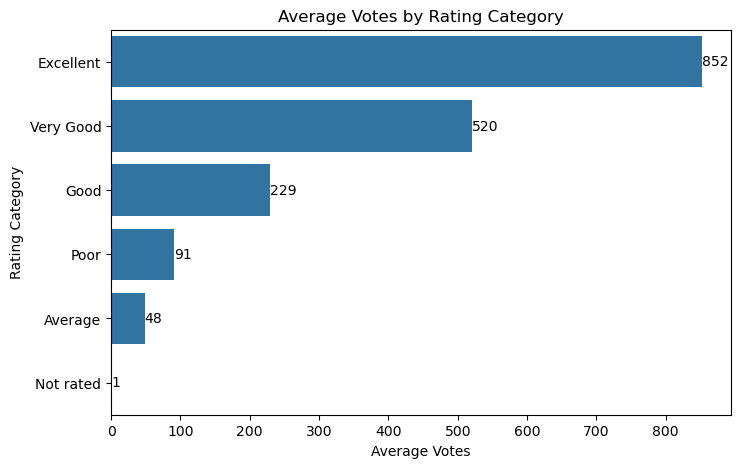

In [23]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=votes_rating.values,
    y=votes_rating.index
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Average Votes by Rating Category")
plt.xlabel("Average Votes")
plt.ylabel("Rating Category")

plt.savefig(
    "../images/average_votes_rating_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insight

- Restaurants receiving more customer votes are generally more popular.
- A positive correlation between votes and ratings suggests that highly rated restaurants tend to attract greater customer engagement.
- Businesses can increase visibility and customer interaction by encouraging reviews and ratings.

# Conclusion

## Key Findings

- Customer voting patterns were analyzed successfully.
- The most popular restaurants based on votes were identified.
- The relationship between votes and ratings was examined.
- Visualizations provide insights into restaurant popularity and customer engagement.

This analysis helps understand how customer interaction relates to restaurant performance.